# NV Diamond Pulse Data Analysis

This notebook analyzes new measurement data from `.npy` files in the `Avg_npy_pulse` folder. Each file corresponds to one crystallographic direction in an NV- 100 faced diamond. The notebook will:
- Examine the data structure and determine the number of pixels
- Visualize time traces for each pixel and direction
- Reconstruct the 2D pixel grid (zig-zag order)
- Visualize the spatial distribution at selected time points

**Data structure:**
- Each `.npy` file: 2D array, first column is time (seconds), remaining columns are pixel voltages (units: volts or as specified)
- Four files: one per crystallographic direction

# 1. find slopes



In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv("results.csv")

axes_order = ["d1", "d2", "d3", "d4"]

f_left_centers_mhz = np.array([
    float(results_df.loc[results_df["name"] == "d1_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d2_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d3_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d4_f_left_meas_MHz", "value"].iloc[0]),
], dtype=float)

odmr_csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"

odmr_df = pd.read_csv(odmr_csv_path, sep=r"\s+")
odmr_df.columns = [c.strip() for c in odmr_df.columns]

freq_col = [c for c in odmr_df.columns if "freq" in c.lower()][0]
sig_col = [c for c in odmr_df.columns if c != freq_col][0]

f_hz_odmr = odmr_df[freq_col].to_numpy(dtype=float)
y_raw_odmr = odmr_df[sig_col].to_numpy(dtype=float)

idx = np.argsort(f_hz_odmr)
f_hz_odmr = f_hz_odmr[idx]
y_raw_odmr = y_raw_odmr[idx]

f_mhz_odmr = f_hz_odmr / 1e6
f_ghz_odmr = f_hz_odmr / 1e9

n_top = max(10, len(y_raw_odmr) // 20)
baseline_odmr = np.mean(np.sort(y_raw_odmr)[-n_top:])
S_odmr = y_raw_odmr / baseline_odmr

print("Tracked lower-transition centers [MHz]:", f_left_centers_mhz)

Tracked lower-transition centers [MHz]: [2791.20577148 2803.93502334 2855.26217136 2866.88305566]


##convert to fractional isgnal#


In [213]:

manual_windows = {
    "d1": (2788.0, 2788.9),
    "d2": (2801.0, 2801.7),
    "d3": (2852.0, 2853.0),
    "d4": (2864.0, 2865.0),
}

manual_windows

{'d1': (2788.0, 2788.9),
 'd2': (2801.0, 2801.7),
 'd3': (2852.0, 2853.0),
 'd4': (2864.0, 2865.0)}

In [214]:
slope_rows = []

for ax in axes_order:
    f_min, f_max = manual_windows[ax]
    center = f_left_centers_mhz[axes_order.index(ax)]

    mask = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask]
    y_fit = S_odmr[mask]

    coeffs = np.polyfit(x_fit, y_fit, deg=1)
    slope = coeffs[0]
    intercept = coeffs[1]

    y_line = slope * x_fit + intercept

    slope_rows.append({
        "axis": ax,
        "center_MHz": center,
        "fit_start_MHz": f_min,
        "fit_end_MHz": f_max,
        "slope_fraction_per_MHz": slope,
        "intercept": intercept,
        "n_points": np.sum(mask)
    })

slopes_df = pd.DataFrame(slope_rows)
display(slopes_df)

,axis,center_MHz,fit_start_MHz,fit_end_MHz,slope_fraction_per_MHz,intercept,n_points
0,d1,2791.205771,2788.0,2788.9,-0.076893,215.358173,5
1,d2,2803.935023,2801.0,2801.7,-0.087911,247.206124,4
2,d3,2855.262171,2852.0,2853.0,-0.034051,98.094483,6
3,d4,2866.883056,2864.0,2865.0,-0.022902,66.562423,6


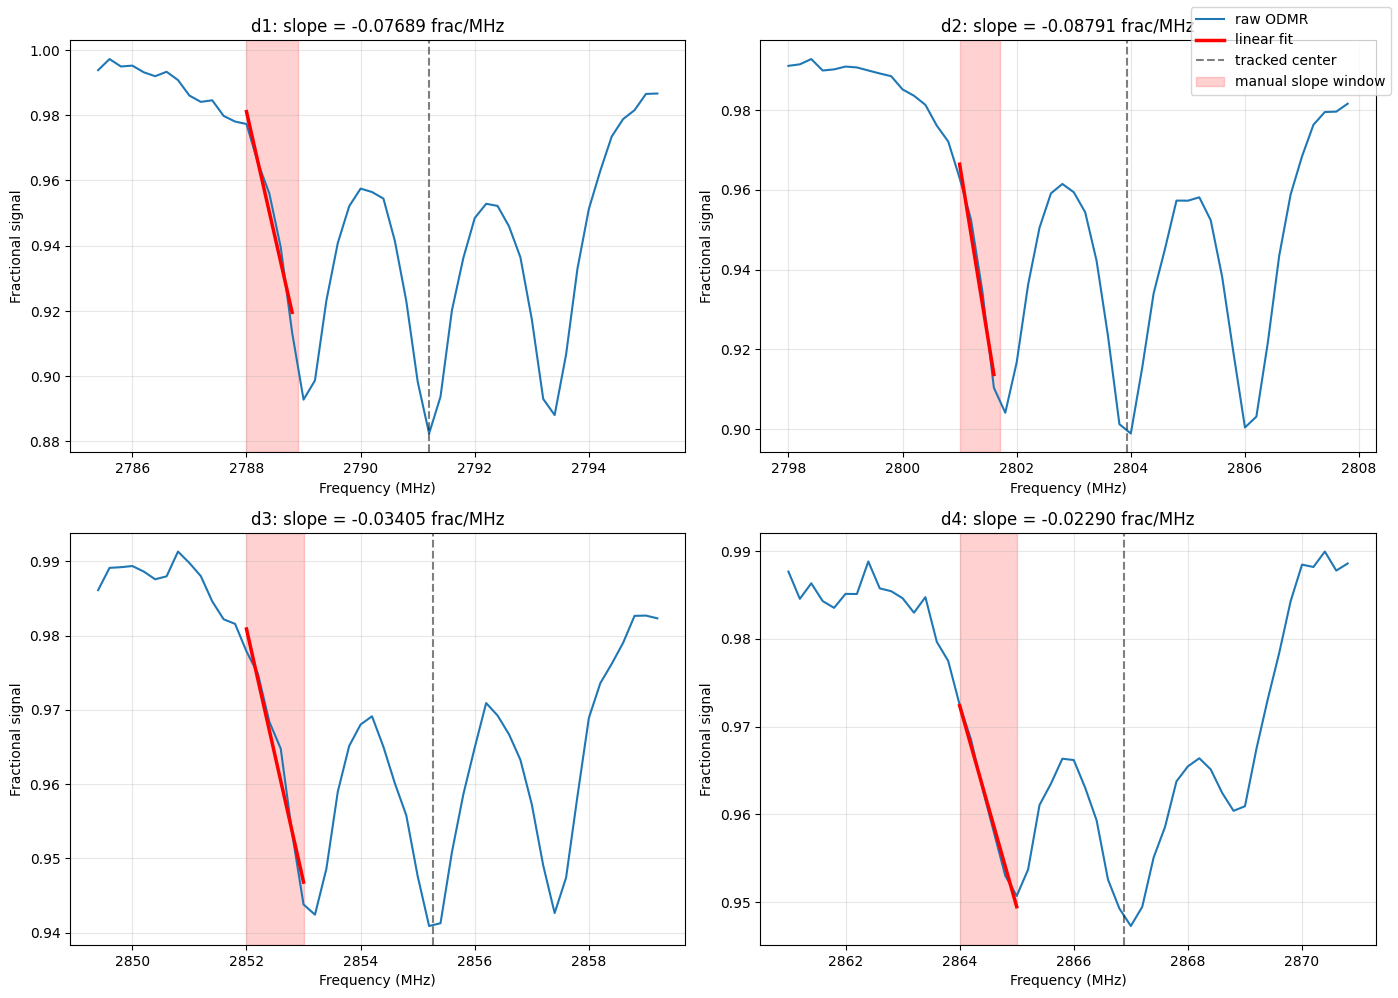

Final manually selected slopes [fractional signal per MHz]:
d1: -0.076893
d2: -0.087911
d3: -0.034051
d4: -0.022902


In [215]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# Wider view around each tracked lower transition
left_span_mhz = 6.0
right_span_mhz = 4.0

for i, ax_name in enumerate(axes_order):
    center = slopes_df.loc[i, "center_MHz"]
    f_min = slopes_df.loc[i, "fit_start_MHz"]
    f_max = slopes_df.loc[i, "fit_end_MHz"]
    slope = slopes_df.loc[i, "slope_fraction_per_MHz"]
    intercept = slopes_df.loc[i, "intercept"]

    mask_zoom = (f_mhz_odmr >= center - left_span_mhz) & (f_mhz_odmr <= center + right_span_mhz)
    mask_fit = (f_mhz_odmr >= f_min) & (f_mhz_odmr <= f_max)

    x_fit = f_mhz_odmr[mask_fit]
    y_line = slope * x_fit + intercept

    axes[i].plot(f_mhz_odmr[mask_zoom], S_odmr[mask_zoom], lw=1.5, label="raw ODMR")
    axes[i].plot(x_fit, y_line, color="red", lw=2.5, label="linear fit")
    axes[i].axvline(center, color="k", ls="--", alpha=0.5, label="tracked center" if i == 0 else None)
    axes[i].axvspan(f_min, f_max, color="red", alpha=0.18, label="manual slope window" if i == 0 else None)

    axes[i].set_title(f"{ax_name}: slope = {slope:.5f} frac/MHz")
    axes[i].set_xlabel("Frequency (MHz)")
    axes[i].set_ylabel("Fractional signal")
    axes[i].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

slopes_fraction_per_MHz = slopes_df["slope_fraction_per_MHz"].to_numpy(dtype=float)

print("Final manually selected slopes [fractional signal per MHz]:")
for i, ax in enumerate(axes_order):
    print(f"{ax}: {slopes_fraction_per_MHz[i]: .6f}")

## 2.  Pulse data analysis and phase selection

In [223]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folder = "Avg_npy_pulse"
npy_files = sorted(glob.glob(os.path.join(folder, "Pulse_avg_d*.npy")))
axes_order = ["d1", "d2", "d3", "d4"]

all_data = [np.load(f) for f in npy_files]

time = all_data[0][:, 0]
voltage_stack = np.stack([arr[:, 1:] for arr in all_data], axis=0)

n_timepoints = voltage_stack.shape[1]
n_pixels = voltage_stack.shape[2]

print("Found files:", npy_files)
print("time shape:", time.shape)
print("voltage_stack shape:", voltage_stack.shape)
print("n_timepoints:", n_timepoints)
print("n_pixels:", n_pixels)
print("grid shape:", grid.shape)
print("time step [s]:", np.mean(np.diff(time)))
print("time range [s]:", time[0], "to", time[-1])

Found files: ['Avg_npy_pulse/Pulse_avg_d1.npy', 'Avg_npy_pulse/Pulse_avg_d2.npy', 'Avg_npy_pulse/Pulse_avg_d3.npy', 'Avg_npy_pulse/Pulse_avg_d4.npy']
time shape: (457,)
voltage_stack shape: (4, 457, 961)
n_timepoints: 457
n_pixels: 961
grid shape: (31, 31)
time step [s]: 0.0003864
time range [s]: 0.0 to 0.1761984


OFF idx: 20 | time [s]: 0.0077280000000000005
POS idx: 150 | time [s]: 0.057960000000000005
NEG idx: 161 | time [s]: 0.0622104


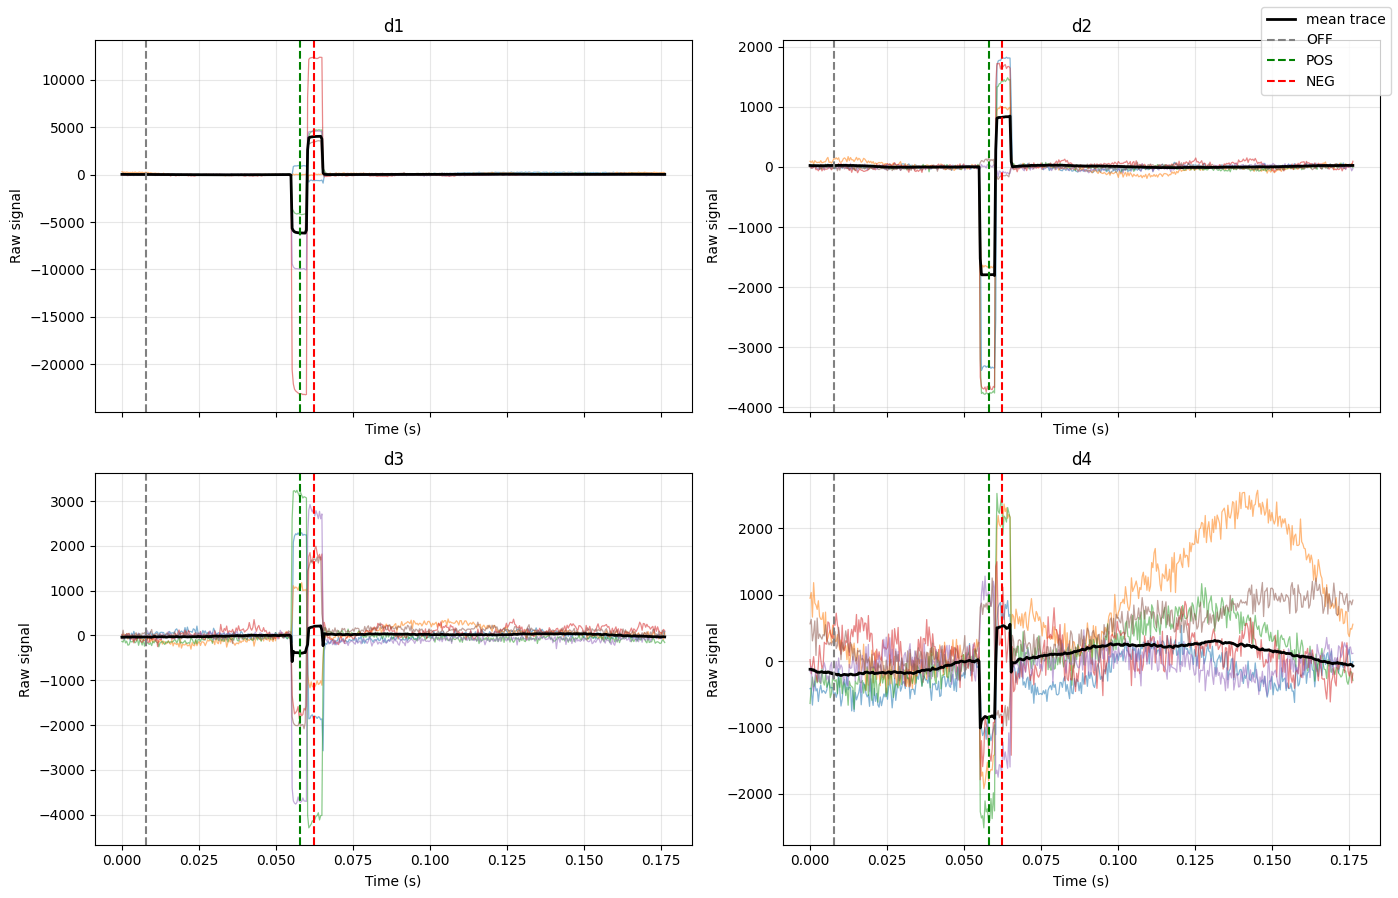

V_off shape: (4, 961)
V_pos shape: (4, 961)
V_neg shape: (4, 961)


In [224]:
# --- Manual choice of one OFF time and one POS / NEG time ---
# Edit these by hand

off_idx = 20
pos_idx = 150
neg_idx = 161

print("OFF idx:", off_idx, "| time [s]:", time[off_idx])
print("POS idx:", pos_idx, "| time [s]:", time[pos_idx])
print("NEG idx:", neg_idx, "| time [s]:", time[neg_idx])


# --- Plot a few raw pixel traces to inspect chosen times ---

pixel_list = [0, 100, 250, 450, 700, 900]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()

for i, ax_name in enumerate(axes_order):
    ax = axes[i]

    for pix in pixel_list:
        ax.plot(time, voltage_stack[i, :, pix], lw=0.9, alpha=0.55)

    mean_trace = np.mean(voltage_stack[i], axis=1)
    ax.plot(time, mean_trace, color="black", lw=2.0, label="mean trace")

    ax.axvline(time[off_idx], color="gray", ls="--", lw=1.5, label="OFF" if i == 0 else None)
    ax.axvline(time[pos_idx], color="green", ls="--", lw=1.5, label="POS" if i == 0 else None)
    ax.axvline(time[neg_idx], color="red", ls="--", lw=1.5, label="NEG" if i == 0 else None)

    ax.set_title(ax_name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Raw signal")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()



# --- Extract OFF / POS / NEG raw frames ---

V_off = voltage_stack[:, off_idx, :]   # shape (4, 961)
V_pos = voltage_stack[:, pos_idx, :]
V_neg = voltage_stack[:, neg_idx, :]

print("V_off shape:", V_off.shape)
print("V_pos shape:", V_pos.shape)
print("V_neg shape:", V_neg.shape)

In [225]:
#Build gread 3131
grid_size = int(np.sqrt(n_pixels))
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size
    if col % 2 == 0:
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx
    else:
        grid[row, grid_size - 1 - col] = idx


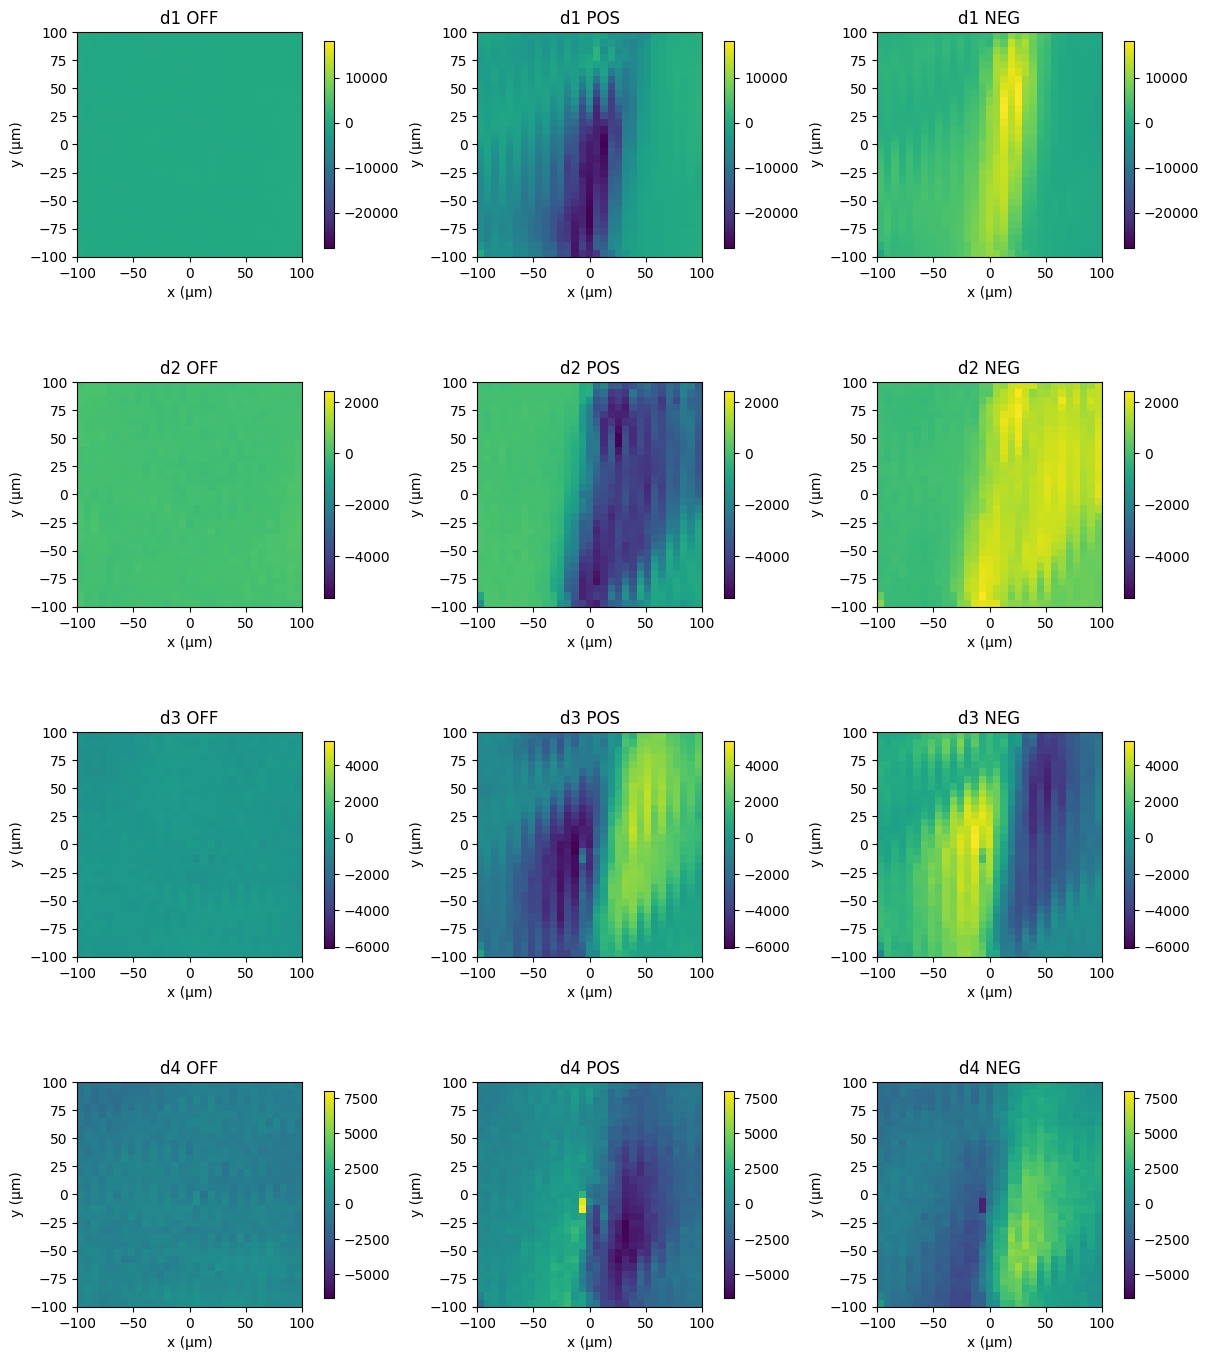

In [226]:
# --- Raw heatmaps ---

extent_um = [-100, 100, -100, 100]

Voff_maps = V_off[:, grid]
Vpos_maps = V_pos[:, grid]
Vneg_maps = V_neg[:, grid]

fig, axes = plt.subplots(4, 3, figsize=(12, 14), constrained_layout=True)

for i, ax_name in enumerate(axes_order):
    arrs = [Voff_maps[i], Vpos_maps[i], Vneg_maps[i]]
    titles = [f"{ax_name} OFF", f"{ax_name} POS", f"{ax_name} NEG"]

    vmin = min(np.nanmin(a) for a in arrs)
    vmax = max(np.nanmax(a) for a in arrs)

    for j in range(3):
        im = axes[i, j].imshow(
            arrs[j],
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )
        axes[i, j].set_title(titles[j])
        axes[i, j].set_xlabel("x (µm)")
        axes[i, j].set_ylabel("y (µm)")
        plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)

plt.show()

dV_pos shape: (4, 961)
dV_neg shape: (4, 961)


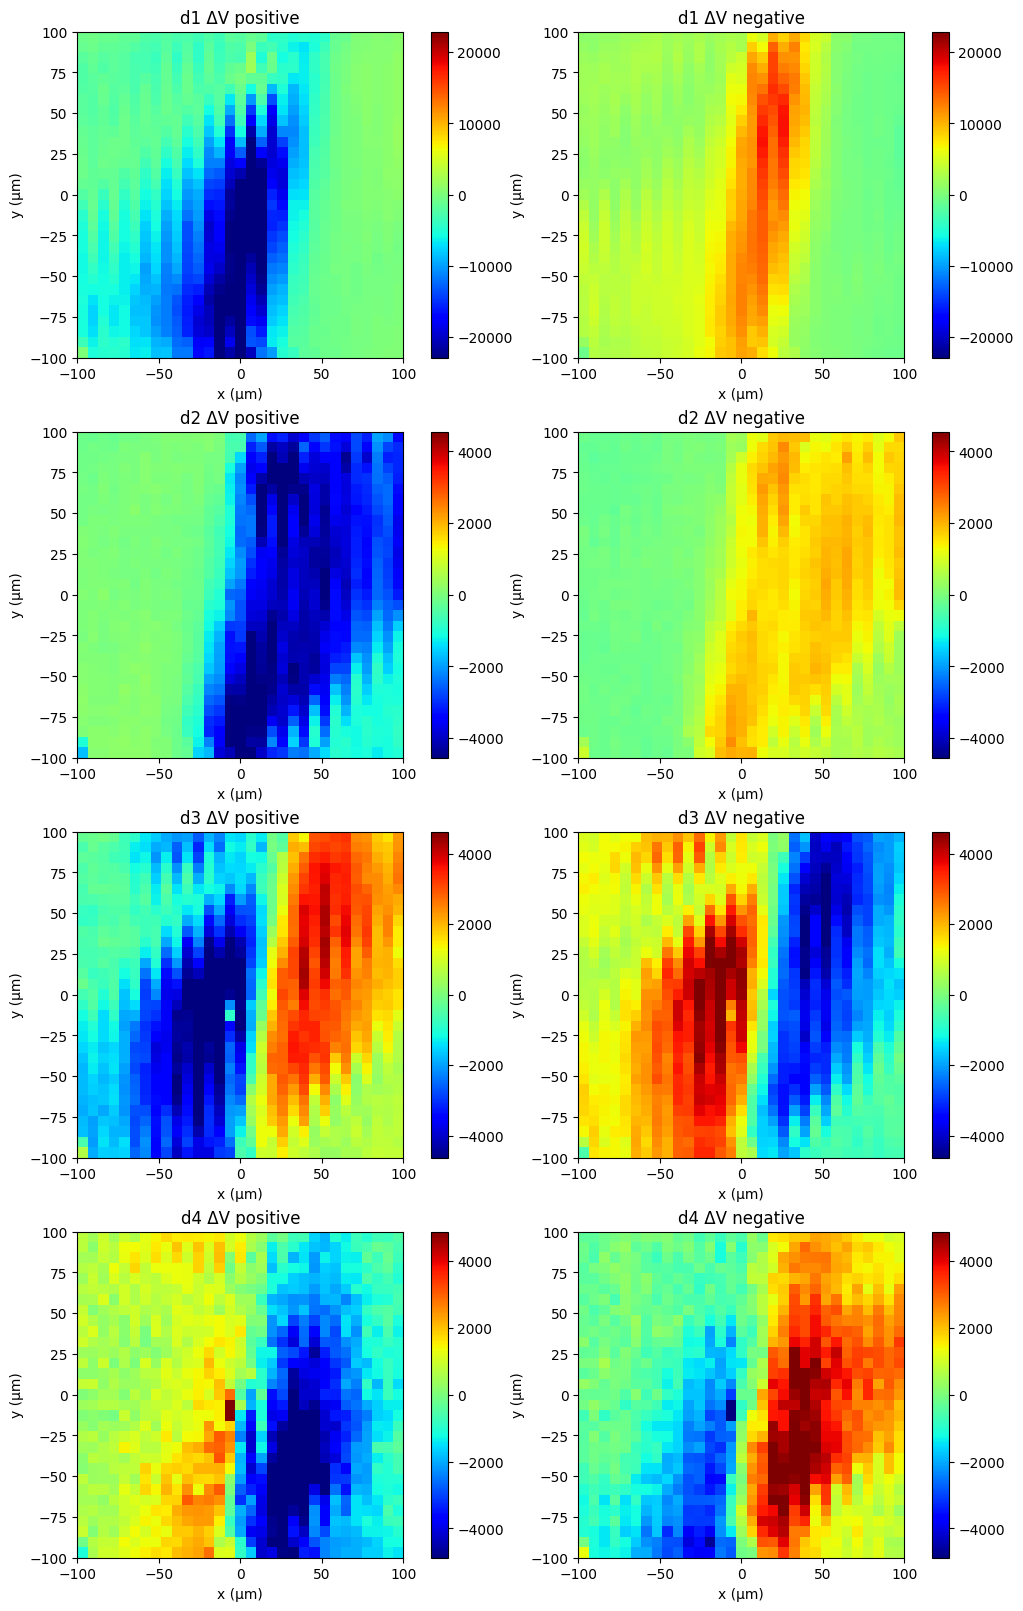

In [ ]:
# --- Raw difference relative to OFF ---

dV_pos = V_pos - V_off
dV_neg = V_neg - V_off

dV_pos_maps = dV_pos[:, grid]
dV_neg_maps = dV_neg[:, grid]



fig, axes = plt.subplots(4, 2, figsize=(10, 16), constrained_layout=True)
for i, ax_name in enumerate(axes_order):
    lim = max(
        np.nanpercentile(np.abs(dV_pos_maps[i]), 95),
        np.nanpercentile(np.abs(dV_neg_maps[i]), 95)
    )
    if lim == 0:
        lim = 1.0

    im1 = axes[i, 0].imshow(
        dV_pos_maps[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    axes[i, 0].set_title(f"{ax_name} ΔV positive")
    axes[i, 0].set_xlabel("x (µm)")
    axes[i, 0].set_ylabel("y (µm)")
    plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    im2 = axes[i, 1].imshow(
        dV_neg_maps[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="jet",
        vmin=-lim,
        vmax=lim
    )
    axes[i, 1].set_title(f"{ax_name} ΔV negative")
    axes[i, 1].set_xlabel("x (µm)")
    axes[i, 1].set_ylabel("y (µm)")
    plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.show()

In [222]:
A_results_df = pd.read_csv("A_results.csv")

A_plus = np.zeros((3, 4), dtype=float)
for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, ax in enumerate(axes_order):
        A_plus[i, j] = float(
            A_results_df.loc[
                (A_results_df["group"] == "A_plus") &
                (A_results_df["row"] == comp) &
                (A_results_df["col"] == ax),
                "value"
            ].iloc[0]
        )

print("A_plus [mT/MHz]:\n", A_plus)

A_plus [mT/MHz]:
 [[-0.00196802 -0.00292597 -0.02287232 -0.02238438]
 [-0.02295424 -0.02253042 -0.00040755 -0.00032227]
 [-0.01562025  0.01578408 -0.01386735  0.01475487]]
